In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
from pathlib import Path
import xarray as xr

from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets
from ewatercycle.forcing import sources

project_dir = Path("/home/niels/BEP-Niels")

temp_dir = project_dir / "temp_runs"
results_dir = project_dir / "results"
figures_dir = project_dir / "Results-figures"

temp_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

print("Project:", project_dir)
print("Results:", results_dir)

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


Project: /home/niels/BEP-Niels
Results: /home/niels/BEP-Niels/results


In [3]:
forcing_file = Path(
    "/home/niels/BEP-Niels/Troepnotebooks/"
    "wflow_forcing_ERA5_2004_2010_with_correct_dem/"
    "work/diagnostic/script/"
    "wflow_ERA5_Rhine_2004_2011.nc"
)

grdc_file = project_dir / "Data Lobith" / "data grdc" / "6435060_Q_Day.Cmd.txt"
shape_file = project_dir / "Rhine" / "Rhine.shp"

print("Forcing bestaat:", forcing_file.exists())
print("GRDC bestaat:", grdc_file.exists())
print("Shapefile bestaat:", shape_file.exists())

print("\nForcing file:")
print(forcing_file)

Forcing bestaat: True
GRDC bestaat: True
Shapefile bestaat: True

Forcing file:
/home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_2004_2010_with_correct_dem/work/diagnostic/script/wflow_ERA5_Rhine_2004_2011.nc


In [4]:
ds = xr.open_dataset(forcing_file)

print(ds)
print("\nVariabelen:")
print(list(ds.data_vars))

print("\nStart forcing:", pd.to_datetime(ds.time.values[0]))
print("Einde forcing:", pd.to_datetime(ds.time.values[-1]))

ds.close()

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 2922, lat: 169, lon: 187, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 23kB 2004-01-01T12:00:00 ... 2011-12-31T...
  * lat        (lat) float64 1kB 52.05 52.02 51.98 51.94 ... 45.97 45.93 45.89
  * lon        (lon) float64 1kB 5.227 5.264 5.3 5.337 ... 11.97 12.01 12.05
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    pr         (time, lat, lon) float32 369MB ...
    time_bnds  (time, bnds) datetime64[ns] 47kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 369MB ...
    pet        (time, lat, lon) float32 369MB ...
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the wflow hydrological model.

Variabelen:
['pr', 'time_bnds', 'lat_bnds', 'lon_bnds', 'tas', 'pet']

Start forcing: 2004-01-01 12:00:00
Einde forcing: 2011-12-31 12:00:00


In [5]:
start_analysis = "2005-01-01"
end_analysis = "2010-12-31"

lat_lobith_model = 51.85
lon_lobith_model = 6.10

low_flow_limit = 1020

print("Analyseperiode:", start_analysis, "tot", end_analysis)
print("Lobith modelpunt:", lat_lobith_model, lon_lobith_model)
print("Low-flow grens:", low_flow_limit, "m3/s")

Analyseperiode: 2005-01-01 tot 2010-12-31
Lobith modelpunt: 51.85 6.1
Low-flow grens: 1020 m3/s


In [7]:
grdc_raw = pd.read_csv(
    grdc_file,
    sep=";",
    comment="#",
    header=None,
    engine="python",
    encoding="latin1"
)

grdc_raw.head()

,0,1,2
0,YYYY-MM-DD,hh:mm,Value
1,1901-01-01,--:--,2035.000
2,1901-01-02,--:--,2270.000
3,1901-01-03,--:--,2445.000
4,1901-01-04,--:--,2325.000


In [8]:
print(grdc_raw.shape)
grdc_raw.head(10)

(43831, 3)


,0,1,2
0,YYYY-MM-DD,hh:mm,Value
1,1901-01-01,--:--,2035.000
2,1901-01-02,--:--,2270.000
3,1901-01-03,--:--,2445.000
4,1901-01-04,--:--,2325.000
5,1901-01-05,--:--,2175.000
6,1901-01-06,--:--,1965.000
7,1901-01-07,--:--,1680.000
8,1901-01-08,--:--,1525.000
9,1901-01-09,--:--,1490.000


In [9]:
dates = pd.to_datetime(grdc_raw.iloc[:, 0], errors="coerce")

q_values = (
    grdc_raw.iloc[:, 2]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

q_values = pd.to_numeric(q_values, errors="coerce")

observed = pd.DataFrame({
    "date": dates,
    "Q_obs_m3s": q_values
})

observed["date"] = observed["date"].dt.normalize()

observed = observed.dropna()
observed = observed[observed["Q_obs_m3s"] > 0]
observed = observed[observed["Q_obs_m3s"] < 20000]

observed_selection = observed[
    (observed["date"] >= start_analysis) &
    (observed["date"] <= end_analysis)
].copy()

observed_selection.head()

/tmp/ipykernel_213959/2634005181.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.


,date,Q_obs_m3s
37987,2005-01-01,2145.0
37988,2005-01-02,2049.0
37989,2005-01-03,2005.0
37990,2005-01-04,2003.0
37991,2005-01-05,2040.0


In [10]:
print("Aantal dagen:", len(observed_selection))
print("Start:", observed_selection["date"].min())
print("Einde:", observed_selection["date"].max())
print("Gemiddelde Q:", observed_selection["Q_obs_m3s"].mean())
print("Minimum Q:", observed_selection["Q_obs_m3s"].min())
print("Aantal dagen onder 1020:", (observed_selection["Q_obs_m3s"] < low_flow_limit).sum())

Aantal dagen: 2191
Start: 2005-01-01 00:00:00
Einde: 2010-12-31 00:00:00
Gemiddelde Q: 2088.0406207211317
Minimum Q: 845.0
Aantal dagen onder 1020: 36


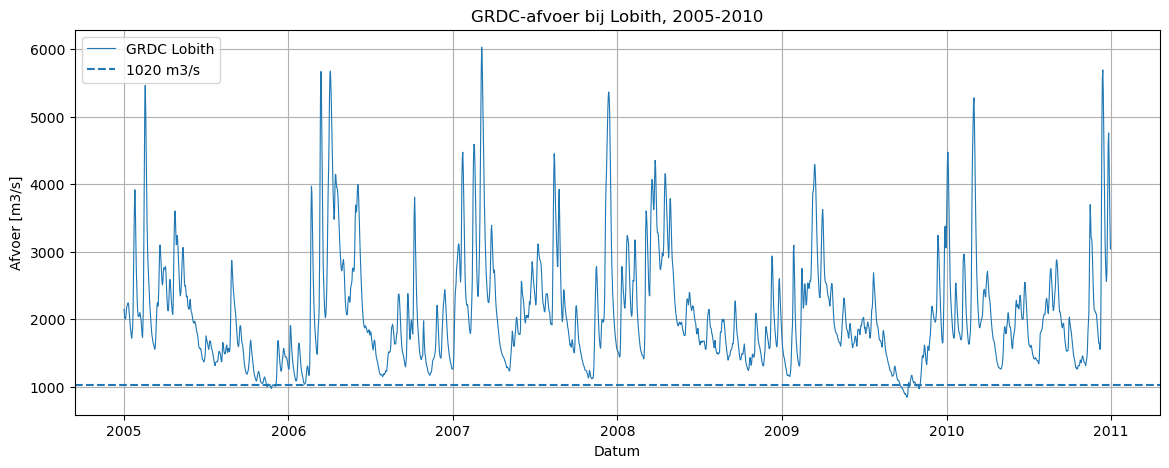

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(
    observed_selection["date"],
    observed_selection["Q_obs_m3s"],
    linewidth=0.8,
    label="GRDC Lobith"
)

plt.axhline(
    low_flow_limit,
    linestyle="--",
    label="1020 m3/s"
)

plt.xlabel("Datum")
plt.ylabel("Afvoer [m3/s]")
plt.title("GRDC-afvoer bij Lobith, 2005-2010")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
forcing_dir = forcing_file.parent

parameter_sets = available_parameter_sets(target_model="wflow")

parameter_set = parameter_sets["wflow_rhine_sbm_nc"]
parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

WflowForcing = sources["WflowForcing"]

forcing = WflowForcing(
    start_time="2004-01-01T00:00:00Z",
    end_time="2011-01-01T00:00:00Z",
    directory=forcing_dir,
    shape=shape_file,
    netcdfinput=forcing_file.name,
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print("Parameter set:")
print(parameter_set.directory)

print("\nConfig bestaat:")
print(parameter_set.config.exists())

print("\nForcing directory:")
print(forcing_dir)

Parameter set:
/data/shared/parameter-sets/wflow_rhine_sbm_nc

Config bestaat:
True

Forcing directory:
/home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_2004_2010_with_correct_dem/work/diagnostic/script


In [13]:
model_check = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file_check, cfg_dir_check = model_check.setup()

cfg_dir_check = Path(cfg_dir_check)
intbl_dir = cfg_dir_check / "intbl"

print("Config file:")
print(cfg_file_check)

print("\nRunmap:")
print(cfg_dir_check)

print("\nIntbl map bestaat:")
print(intbl_dir.exists())

Config file:
/home/niels/BEP-Niels/notebooks/wflow_20260601_123411/wflow_ewatercycle.ini

Runmap:
/home/niels/BEP-Niels/notebooks/wflow_20260601_123411

Intbl map bestaat:
True


In [14]:
tbl_files = sorted(intbl_dir.glob("*.tbl"))

print("Aantal tbl-bestanden:", len(tbl_files))

for file in tbl_files:
    print(file.name)

Aantal tbl-bestanden: 22
CanopyGapFraction.tbl
Cfmax.tbl
EoverR.tbl
FirstZoneCapacity.tbl
FirstZoneKsatVer.tbl
FirstZoneMinCapacity.tbl
InfiltCapPath.tbl
InfiltCapSoil.tbl
M.tbl
MaxCanopyStorage.tbl
MaxLeakage.tbl
N.tbl
N_Floodplain.tbl
N_River.tbl
PathFrac.tbl
RootingDepth.tbl
TT.tbl
TTI.tbl
WHC.tbl
cf_soil.tbl
thetaR.tbl
thetaS.tbl


In [15]:
relevant_tbls = [
    "M.tbl",
    "FirstZoneKsatVer.tbl",
    "N_River.tbl",
    "N.tbl",
    "FirstZoneCapacity.tbl",
    "FirstZoneMinCapacity.tbl",
    "RootingDepth.tbl"
]

for tbl in relevant_tbls:
    path = intbl_dir / tbl
    print(tbl, "bestaat:", path.exists())

M.tbl bestaat: True
FirstZoneKsatVer.tbl bestaat: True
N_River.tbl bestaat: True
N.tbl bestaat: True
FirstZoneCapacity.tbl bestaat: True
FirstZoneMinCapacity.tbl bestaat: True
RootingDepth.tbl bestaat: True


In [16]:
for tbl in ["M.tbl", "FirstZoneKsatVer.tbl"]:
    print("\n---", tbl, "---")
    
    path = intbl_dir / tbl
    
    with open(path, "r") as f:
        lines = f.readlines()
    
    for line in lines[:10]:
        print(line.strip())


--- M.tbl ---
<,7]	1	1 1504
<,7]	2	1 193
<,7]	3	1 12880
<,7]	4	1 183
<,7]	5	1 176
<,7]	6	1 183
<,7]	7	1 133
<,7]	8	1 1450
<,7]	9	1 183
<,7]	10	1  190

--- FirstZoneKsatVer.tbl ---
<,7]	1  1  8000
<,7]	2  1  100
<,7]	3  1  100
<,7]	4  1  1000
<,7]	5  1  1000
<,7]	6  1  1000
<,7]	7  1  1500
<,7]	8  1  100
<,7]	9  1  1000
<,7]	10 1  1000


In [17]:
try:
    model_check.finalize()
except:
    pass

print("Check-model afgesloten")

Check-model afgesloten


In [18]:
def multiply_tbl_values(tbl_file, factor):
    tbl_file = Path(tbl_file)
    
    new_lines = []
    
    with open(tbl_file, "r") as f:
        lines = f.readlines()
    
    for line in lines:
        stripped = line.strip()
        
        if stripped == "" or stripped.startswith("#"):
            new_lines.append(line)
            continue
        
        parts = stripped.split()
        
        try:
            old_value = float(parts[-1])
            new_value = old_value * factor
            parts[-1] = str(new_value)
            new_lines.append("\t".join(parts) + "\n")
        except:
            new_lines.append(line)
    
    with open(tbl_file, "w") as f:
        f.writelines(new_lines)

In [22]:
def run_wflow_test(tbl_name=None, factor=1.0, output_name="Q_sim_m3s", progress_every=100):
    model = Wflow(
        parameter_set=parameter_set,
        forcing=forcing
    )
    
    cfg_file, cfg_dir = model.setup()
    cfg_dir = Path(cfg_dir)
    
    print("Runmap:", cfg_dir)
    
    if tbl_name is not None:
        tbl_file = cfg_dir / "intbl" / tbl_name
        
        if not tbl_file.exists():
            raise FileNotFoundError(f"Niet gevonden: {tbl_file}")
        
        multiply_tbl_values(tbl_file, factor)
        print(tbl_name, "vermenigvuldigd met", factor)
    
    model.initialize(cfg_file)
    
    dates = []
    q_values = []
    
    step = 0
    
    # Dit is de totale modelperiode die we nu gebruiken
    run_start = pd.to_datetime("2004-01-01")
    run_end = pd.to_datetime("2011-01-01")
    total_steps = (run_end - run_start).days
    
    while model.time < model.end_time:
        model.update()
        step = step + 1
        
        q = model.get_value_at_coords(
            "RiverRunoff",
            lat=[lat_lobith_model],
            lon=[lon_lobith_model]
        )[0]
        
        dates.append(model.time_as_datetime)
        q_values.append(float(q))
        
        if step == 1 or step % progress_every == 0:
            percentage = 100 * step / total_steps
            current_date = str(model.time_as_datetime)[:10]
            
            print(
                f"\rVoortgang: {step}/{total_steps} dagen "
                f"({percentage:.1f}%) - datum: {current_date}",
                end="",
                flush=True
            )
    
    print("\nModelrun klaar")
    
    try:
        model.finalize()
    except:
        pass
    
    output = pd.DataFrame({
        "date": pd.to_datetime(dates).tz_localize(None).normalize(),
        output_name: q_values
    })
    
    output = output[
        (output["date"] >= start_analysis) &
        (output["date"] <= end_analysis)
    ].copy()
    
    output.to_csv(results_dir / f"{output_name}.csv", index=False)
    
    return output

In [20]:
def calculate_scores(comparison, sim_col):
    obs = comparison["Q_obs_m3s"]
    sim = comparison[sim_col]
    
    rmse = np.sqrt(((sim - obs) ** 2).mean())
    bias = sim.mean() - obs.mean()
    
    log_obs = np.log(obs + 1)
    log_sim = np.log(sim + 1)
    
    log_nse = 1 - ((log_sim - log_obs) ** 2).sum() / ((log_obs - log_obs.mean()) ** 2).sum()
    
    obs_low_days = (obs < low_flow_limit).sum()
    sim_low_days = (sim < low_flow_limit).sum()
    
    q10_obs = obs.quantile(0.10)
    q10_sim = sim.quantile(0.10)
    
    q17_obs = obs.quantile(0.17)
    q17_sim = sim.quantile(0.17)
    
    scores = {
        "RMSE": rmse,
        "Bias": bias,
        "log_NSE": log_nse,
        "obs_days_under_1020": obs_low_days,
        "sim_days_under_1020": sim_low_days,
        "difference_days_under_1020": sim_low_days - obs_low_days,
        "Q10_obs": q10_obs,
        "Q10_sim": q10_sim,
        "Q10_difference": q10_sim - q10_obs,
        "Q17_obs": q17_obs,
        "Q17_sim": q17_sim,
        "Q17_difference": q17_sim - q17_obs,
    }
    
    return pd.DataFrame([scores])

In [21]:
baseline = run_wflow_test(
    tbl_name=None,
    factor=1.0,
    output_name="Q_baseline_m3s"
)

comparison_baseline = pd.merge(
    observed_selection,
    baseline,
    on="date",
    how="inner"
)

scores_baseline = calculate_scores(
    comparison_baseline,
    sim_col="Q_baseline_m3s"
)

scores_baseline["run"] = "baseline"

scores_baseline

Runmap: /home/niels/BEP-Niels/notebooks/wflow_20260601_123659


,RMSE,Bias,log_NSE,obs_days_under_1020,sim_days_under_1020,difference_days_under_1020,Q10_obs,Q10_sim,Q10_difference,Q17_obs,Q17_sim,Q17_difference,run
0,1856.116719,874.316401,-2.297847,36,397,361,1262.0,670.093872,-591.906128,1397.0,966.937585,-430.062415,baseline


In [23]:
m_075 = run_wflow_test(
    tbl_name="M.tbl",
    factor=0.75,
    output_name="Q_M_0p75_m3s",
    progress_every=100
)

Runmap: /home/niels/BEP-Niels/notebooks/wflow_20260601_124838
M.tbl vermenigvuldigd met 0.75
Voortgang: 2500/2557 dagen (97.8%) - datum: 2010-11-04
Modelrun klaar


In [24]:
comparison_baseline = pd.merge(
    observed_selection,
    baseline,
    on="date",
    how="inner"
)

scores_baseline = calculate_scores(
    comparison_baseline,
    sim_col="Q_baseline_m3s"
)

scores_baseline["run"] = "baseline"

scores_baseline

,RMSE,Bias,log_NSE,obs_days_under_1020,sim_days_under_1020,difference_days_under_1020,Q10_obs,Q10_sim,Q10_difference,Q17_obs,Q17_sim,Q17_difference,run
0,1856.116719,874.316401,-2.297847,36,397,361,1262.0,670.093872,-591.906128,1397.0,966.937585,-430.062415,baseline


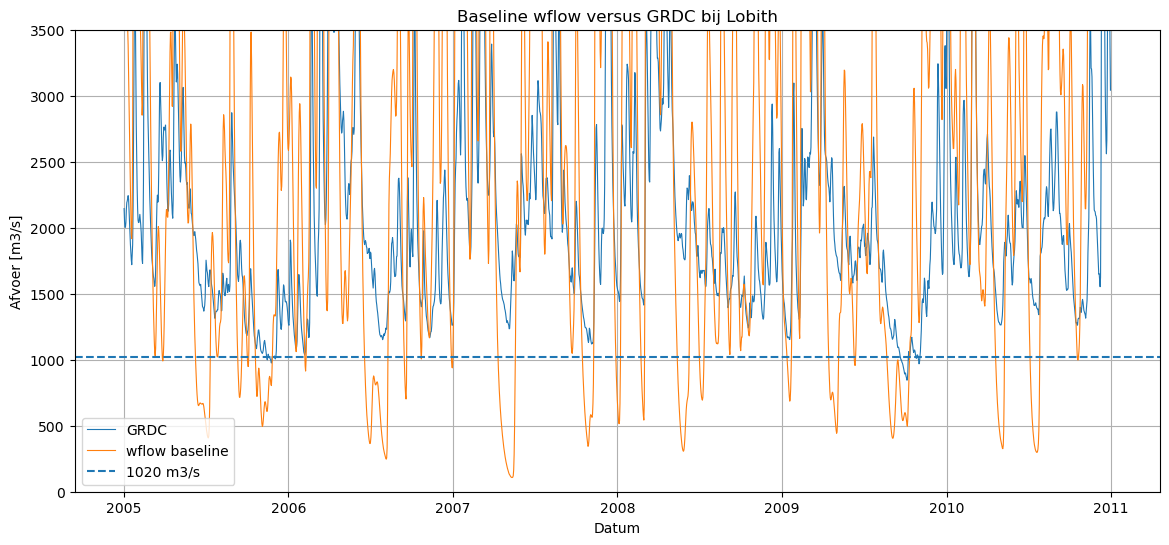

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_baseline["date"],
    comparison_baseline["Q_obs_m3s"],
    label="GRDC",
    linewidth=0.8
)

plt.plot(
    comparison_baseline["date"],
    comparison_baseline["Q_baseline_m3s"],
    label="wflow baseline",
    linewidth=0.8
)

plt.axhline(
    low_flow_limit,
    linestyle="--",
    label="1020 m3/s"
)

plt.ylim(0, 3500)
plt.xlabel("Datum")
plt.ylabel("Afvoer [m3/s]")
plt.title("Baseline wflow versus GRDC bij Lobith")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
comparison_m_075 = pd.merge(
    observed_selection,
    m_075,
    on="date",
    how="inner"
)

scores_m_075 = calculate_scores(
    comparison_m_075,
    sim_col="Q_M_0p75_m3s"
)

scores_m_075["run"] = "M x 0.75"

scores_m_075

,RMSE,Bias,log_NSE,obs_days_under_1020,sim_days_under_1020,difference_days_under_1020,Q10_obs,Q10_sim,Q10_difference,Q17_obs,Q17_sim,Q17_difference,run
0,1857.27002,874.815699,-2.30057,36,397,361,1262.0,669.155701,-592.844299,1397.0,966.864685,-430.135315,M x 0.75


In [27]:
score_table = pd.concat(
    [scores_baseline, scores_m_075],
    ignore_index=True
)

score_table = score_table[
    [
        "run",
        "RMSE",
        "Bias",
        "log_NSE",
        "obs_days_under_1020",
        "sim_days_under_1020",
        "difference_days_under_1020",
        "Q10_obs",
        "Q10_sim",
        "Q10_difference",
        "Q17_obs",
        "Q17_sim",
        "Q17_difference",
    ]
]

score_table

,run,RMSE,Bias,log_NSE,obs_days_under_1020,sim_days_under_1020,difference_days_under_1020,Q10_obs,Q10_sim,Q10_difference,Q17_obs,Q17_sim,Q17_difference
0,baseline,1856.116719,874.316401,-2.297847,36,397,361,1262.0,670.093872,-591.906128,1397.0,966.937585,-430.062415
1,M x 0.75,1857.270020,874.815699,-2.300570,36,397,361,1262.0,669.155701,-592.844299,1397.0,966.864685,-430.135315


In [28]:
def evaluate_run(sim_data, sim_col, run_name):
    comparison = pd.merge(
        observed_selection,
        sim_data,
        on="date",
        how="inner"
    )
    
    scores = calculate_scores(
        comparison,
        sim_col=sim_col
    )
    
    scores["run"] = run_name
    
    return comparison, scores

In [29]:
m_025 = run_wflow_test(
    tbl_name="M.tbl",
    factor=0.25,
    output_name="Q_M_0p25_m3s",
    progress_every=100
)

comparison_m_025, scores_m_025 = evaluate_run(
    sim_data=m_025,
    sim_col="Q_M_0p25_m3s",
    run_name="M x 0.25"
)

scores_m_025

Runmap: /home/niels/BEP-Niels/notebooks/wflow_20260601_130144
M.tbl vermenigvuldigd met 0.25
Voortgang: 2500/2557 dagen (97.8%) - datum: 2010-11-04
Modelrun klaar


,RMSE,Bias,log_NSE,obs_days_under_1020,sim_days_under_1020,difference_days_under_1020,Q10_obs,Q10_sim,Q10_difference,Q17_obs,Q17_sim,Q17_difference,run
0,1856.226213,873.313284,-2.303756,36,398,362,1262.0,667.71936,-594.28064,1397.0,966.355585,-430.644415,M x 0.25


In [30]:
m_200 = run_wflow_test(
    tbl_name="M.tbl",
    factor=2.00,
    output_name="Q_M_2p00_m3s",
    progress_every=100
)

comparison_m_200, scores_m_200 = evaluate_run(
    sim_data=m_200,
    sim_col="Q_M_2p00_m3s",
    run_name="M x 2.00"
)

scores_m_200

Runmap: /home/niels/BEP-Niels/notebooks/wflow_20260601_131248
M.tbl vermenigvuldigd met 2.0
Voortgang: 2500/2557 dagen (97.8%) - datum: 2010-11-04
Modelrun klaar


,RMSE,Bias,log_NSE,obs_days_under_1020,sim_days_under_1020,difference_days_under_1020,Q10_obs,Q10_sim,Q10_difference,Q17_obs,Q17_sim,Q17_difference,run
0,1856.583231,874.736081,-2.297103,36,397,361,1262.0,670.228516,-591.771484,1397.0,967.129614,-429.870386,M x 2.00


In [31]:
score_table_m = pd.concat(
    [
        scores_baseline,
        scores_m_075,
        scores_m_025,
        scores_m_200
    ],
    ignore_index=True
)

score_table_m = score_table_m[
    [
        "run",
        "RMSE",
        "Bias",
        "log_NSE",
        "obs_days_under_1020",
        "sim_days_under_1020",
        "difference_days_under_1020",
        "Q10_obs",
        "Q10_sim",
        "Q10_difference",
        "Q17_obs",
        "Q17_sim",
        "Q17_difference"
    ]
]

score_table_m

,run,RMSE,Bias,log_NSE,obs_days_under_1020,sim_days_under_1020,difference_days_under_1020,Q10_obs,Q10_sim,Q10_difference,Q17_obs,Q17_sim,Q17_difference
0,baseline,1856.116719,874.316401,-2.297847,36,397,361,1262.0,670.093872,-591.906128,1397.0,966.937585,-430.062415
1,M x 0.75,1857.270020,874.815699,-2.300570,36,397,361,1262.0,669.155701,-592.844299,1397.0,966.864685,-430.135315
2,M x 0.25,1856.226213,873.313284,-2.303756,36,398,362,1262.0,667.719360,-594.280640,1397.0,966.355585,-430.644415
3,M x 2.00,1856.583231,874.736081,-2.297103,36,397,361,1262.0,670.228516,-591.771484,1397.0,967.129614,-429.870386
